In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [ ]:
df=pd.read_csv("spam.csv", encoding="latin-1")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df=df[["v1", "v2"]]
df.columns=["label", "message"]
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


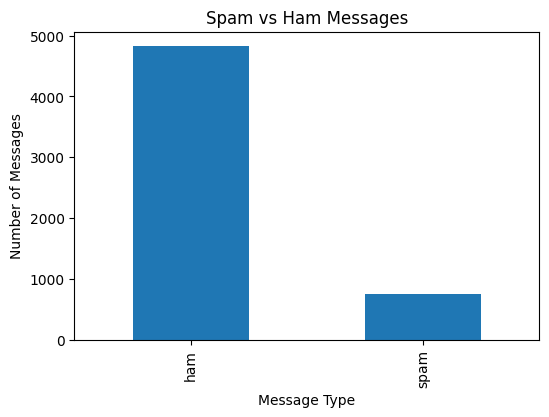

In [ ]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

plt.figure(figsize=(6, 4))

df["label"].value_counts().plot(kind="bar")

plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.title("Spam vs Ham Messages")

plt.show()

In [ ]:
df["label_num"]=df["label"].map({"ham":0, "spam":1})
print(df.head())

  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0


In [ ]:
def clean_text(text):
  text = text.lower()

  # Remove punctuation and special characters
  text = re.sub(r"[^a-z A-Z\s]", "", text)

  # Replace extra spaces with a single space
  text = re.sub(r"\s+", " ", text).strip()

  return text

df["clean message"] = df["message"].apply(clean_text)

df[["message", "clean message"]].head()

<bound method NDFrame.head of                                                 message                                      clean message
0     Go until jurong point, crazy.. Available only ...  gountiljurongpointcrazyavailableonlyinbugisngr...
1                         Ok lar... Joking wif u oni...                                 oklarjokingwifuoni
2     Free entry in 2 a wkly comp to win FA Cup fina...  freeentryinawklycomptowinfacupfinaltktsstmayte...
3     U dun say so early hor... U c already then say...                  udunsaysoearlyhorucalreadythensay
4     Nah I don't think he goes to usf, he lives aro...    nahidontthinkhegoestousfhelivesaroundherethough
...                                                 ...                                                ...
5567  This is the 2nd time we have tried 2 contact u...  thisisthendtimewehavetriedcontactuuhavewonthep...
5568              Will Ì_ b going to esplanade fr home?                        willbgoingtoesplanadefrhome
5569  Pity, * was in mood for that. So...any other s...          pitywasinmoodforthatsoanyothersuggestions
5570  The guy did some bitching but I acted like i'd...  theguydidsomebitchingbutiactedlikeidbeinterest...
5571                         Rofl. Its true to its name                               roflitstruetoitsname

[5572 rows x 2 columns]>

In [ ]:
X=df["clean message"]
y=df["label_num"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [ ]:
vectorizer=TfidfVectorizer(stop_words="english", max_features=5000)
X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 4125)
Testing TF-IDF shape: (1115, 4125)


In [ ]:
model=MultinomialNB()
model.fit(X_train_tfidf, y_train)
print("Model trained completed successfully!")

Model trained completed successfully!


In [ ]:
y_pred=model.predict(X_test_tfidf)
print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
accuracy=accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8726457399103139


In [ ]:
precision=precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 1.0


In [ ]:
recall=recall_score(y_test, y_pred)
print("Recall Score:", recall)

Recall Score: 0.04697986577181208


In [ ]:
f1=f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.08974358974358974


In [ ]:
print("----------MODEL PERFORMANCE----------")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall Score:", recall)
print("F1 Score:", f1)

----------MODEL PERFORMANCE----------
Accuracy: 0.8726457399103139
Precision: 1.0
Recall Score: 0.04697986577181208
F1 Score: 0.08974358974358974


Confusion Matrix:
[[966   0]
 [142   7]]


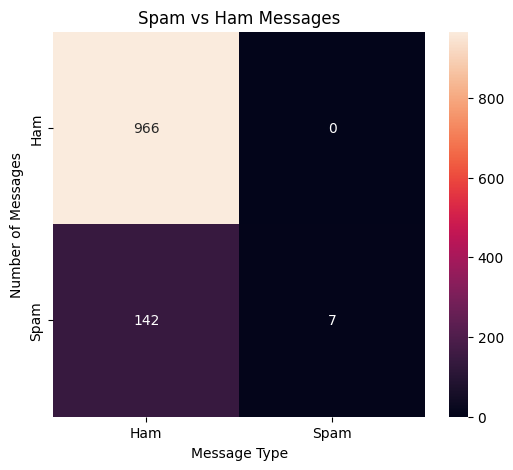

In [ ]:
cm=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.title("Spam vs Ham Messages")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       966
        spam       1.00      0.05      0.09       149

    accuracy                           0.87      1115
   macro avg       0.94      0.52      0.51      1115
weighted avg       0.89      0.87      0.82      1115



In [ ]:
def predict_message(message):
  cleaned=clean_text(message)
  transformed=vectorizer.transform([cleaned])
  prediction=model.predict(transformed)[0]
  if prediction==1:
    return "SPAM"
  else:
    return "HAM"

In [ ]:
message="Congratulations! You have won a free size. Call now!"
result=predict_message(message)
print("Message:", message)
print("Prediction:", result)

Message: Congratulations! You have won a free size. Call now!
Prediction: HAM


In [ ]:
message="Hey, are you coming to college tomorrow?"
result=predict_message(message)
print("Message:", message)
print("Prediction:", result)

Message: Hey, are you coming to college tomorrow?
Prediction: HAM
